In [ ]:
# Install
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn -q

# Imports
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ All imports successful")
print(f"TensorFlow version: {tf.__version__}")

✅ All imports successful
TensorFlow version: 2.20.0


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


In [ ]:
import os

# Unzip the uploaded archive
!unzip "archive (2).zip"

# Decompress the .gz file to get the data file
!gunzip corrected.gz

# See what came out after unzipping and decompression
!ls -l

Archive:  archive (2).zip
  inflating: corrected.gz            
  inflating: corrected/corrected     
  inflating: kddcup.data.corrected   
  inflating: kddcup.data.gz          
  inflating: kddcup.data/kddcup.data  
  inflating: kddcup.data_10_percent.gz  
  inflating: kddcup.data_10_percent/kddcup.data_10_percent  
  inflating: kddcup.data_10_percent_corrected  
  inflating: kddcup.names            
  inflating: kddcup.newtestdata_10_percent_unlabeled.gz  
  inflating: kddcup.newtestdata_10_percent_unlabeled/kddcup.newtestdata_10_percent_unlabeled  
  inflating: kddcup.testdata.unlabeled.gz  
  inflating: kddcup.testdata.unlabeled/kddcup.testdata.unlabeled  
  inflating: kddcup.testdata.unlabeled_10_percent.gz  
  inflating: kddcup.testdata.unlabeled_10_percent/kddcup.testdata.unlabeled_10_percent  
  inflating: training_attack_types   
  inflating: typo-correction.txt     
gzip: corrected already exists; do you wish to overwrite (y or n)? ^C
total 923120
-rw-r--r-- 1 root root  9205

In [ ]:
import os

file_path = 'kddcup.data_10_percent_corrected'
if os.path.exists(file_path):
    print(f"✅ File '{file_path}' exists and is ready for use.")
else:
    print(f"❌ File '{file_path}' does not exist. Please re-upload it.")

❌ File 'kddcup.data_10_percent_corrected' does not exist. Please re-upload it.


### Data Preprocessing Steps

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

# Column names
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','label'
]

# Load the file
df = pd.read_csv('kddcup.data_10_percent_corrected', names=columns)

print("Shape:", df.shape)
display(df.head())

Shape: (494021, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,http,SF,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal.
1,0,tcp,http,SF,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal.
2,0,tcp,http,SF,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
3,0,tcp,http,SF,219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
4,0,tcp,http,SF,217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.


#### Check initial data and types

In [ ]:
# See all attack types and how many records each has
print("=== Label Counts ===")
print(df['label'].value_counts())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Data Types ===")
print(df.dtypes)

=== Label Counts ===
label
smurf.              280790
neptune.            107201
normal.              97278
back.                 2203
satan.                1589
ipsweep.              1247
portsweep.            1040
warezclient.          1020
teardrop.              979
pod.                   264
nmap.                  231
guess_passwd.           53
buffer_overflow.        30
land.                   21
warezmaster.            20
imap.                   12
rootkit.                10
loadmodule.              9
ftp_write.               8
multihop.                7
phf.                     4
perl.                    3
spy.                     2
Name: count, dtype: int64

=== Missing Values ===
duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot  

#### Map labels to broader categories

In [ ]:
def map_label(label):
    if label == 'normal.':
        return 'Normal'
    elif label in ['back.','land.','neptune.','pod.','smurf.','teardrop.']:
        return 'DoS'
    elif label in ['ipsweep.','nmap.','portsweep.','satan.']:
        return 'Probe'
    elif label in ['ftp_write.','guess_passwd.','imap.','multihop.',
                   'phf.','spy.','warezclient.','warezmaster.']:
        return 'R2L'
    else:
        return 'U2R'

# Apply to every row in the label column
df['label'] = df['label'].apply(map_label)

# Confirm — should now show exactly 5 labels
print(df['label'].value_counts())

label
DoS       391458
Normal     97278
Probe       4107
R2L         1126
U2R           52
Name: count, dtype: int64


#### Encode categorical features and labels

In [ ]:
le = LabelEncoder()

# Encode the 3 text feature columns
cat_cols = ['protocol_type', 'service', 'flag']
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Encode the label column
df['label'] = le.fit_transform(df['label'])

# Confirm
print("Encoding done!")
display(df[['protocol_type', 'service', 'flag', 'label']].head(10))

Encoding done!


,protocol_type,service,flag,label
0,1,22,9,1
1,1,22,9,1
2,1,22,9,1
3,1,22,9,1
4,1,22,9,1
5,1,22,9,1
6,1,22,9,1
7,1,22,9,1
8,1,22,9,1
9,1,22,9,1


#### Normalize features and split into X and y

In [ ]:
# Separate features and labels
# Separate features and labels
X = df.drop('label', axis=1)   # Only drop the label column
y = df['label']                 # Only the label column

# Normalize all feature values between 0 and 1
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("Features shape:", X_scaled.shape)   # Should be (494021, 41)
print("Labels shape:", y.shape)            # Should be (494021,)
print("Min value:", X_scaled.min())        # Should be 0.0
print("Max value:", X_scaled.max())        # Should be 1.0

Features shape: (494021, 41)
Labels shape: (494021,)
Min value: 0.0
Max value: 1.0


#### Perform train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,      # 20% for testing
    random_state=42     # Fixed seed so results are reproducible
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 395216
Testing samples:  98805


In [ ]:
import os
if os.path.exists('kddcup.data_10_percent_corrected'):
    print(f"✅ Ready: {os.path.getsize('kddcup.data_10_percent_corrected') / (1024*1024):.1f} MB")

✅ Ready: 71.4 MB


In [ ]:
!unzip archive.zip

# See what came out
!ls

unzip:  cannot find or open archive.zip, archive.zip.zip or archive.zip.ZIP.
'archive (2).zip'		    kddcup.newtestdata_10_percent_unlabeled
 corrected			    kddcup.newtestdata_10_percent_unlabeled.gz
 corrected.gz			    kddcup.testdata.unlabeled
 kddcup.data			    kddcup.testdata.unlabeled_10_percent
 kddcup.data_10_percent		    kddcup.testdata.unlabeled_10_percent.gz
 kddcup.data_10_percent_corrected   kddcup.testdata.unlabeled.gz
 kddcup.data_10_percent.gz	    sample_data
 kddcup.data.corrected		    training_attack_types
 kddcup.data.gz			    typo-correction.txt
 kddcup.names


In [ ]:
# Imports
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

# Column names
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','label'
]

# Load the file
df = pd.read_csv('kddcup.data_10_percent_corrected', names=columns)

print("Shape:", df.shape)
df.head()

Shape: (494021, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,http,SF,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal.
1,0,tcp,http,SF,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal.
2,0,tcp,http,SF,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
3,0,tcp,http,SF,219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
4,0,tcp,http,SF,217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.


In [ ]:
print("df shape:", df.shape)
print("df columns:", df.columns.tolist())

df shape: (494021, 42)
df columns: ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label']


In [ ]:
# See all attack types and how many records each has
print("=== Label Counts ===")
print(df['label'].value_counts())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Data Types ===")
print(df.dtypes)

=== Label Counts ===
label
smurf.              280790
neptune.            107201
normal.              97278
back.                 2203
satan.                1589
ipsweep.              1247
portsweep.            1040
warezclient.          1020
teardrop.              979
pod.                   264
nmap.                  231
guess_passwd.           53
buffer_overflow.        30
land.                   21
warezmaster.            20
imap.                   12
rootkit.                10
loadmodule.              9
ftp_write.               8
multihop.                7
phf.                     4
perl.                    3
spy.                     2
Name: count, dtype: int64

=== Missing Values ===
duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot  

In [ ]:
def map_label(label):
    if label == 'normal.':
        return 'Normal'
    elif label in ['back.','land.','neptune.','pod.','smurf.','teardrop.']:
        return 'DoS'
    elif label in ['ipsweep.','nmap.','portsweep.','satan.']:
        return 'Probe'
    elif label in ['ftp_write.','guess_passwd.','imap.','multihop.',
                   'phf.','spy.','warezclient.','warezmaster.']:
        return 'R2L'
    else:
        return 'U2R'

# Apply to every row in the label column
df['label'] = df['label'].apply(map_label)

# Confirm — should now show exactly 5 labels
print(df['label'].value_counts())

label
DoS       391458
Normal     97278
Probe       4107
R2L         1126
U2R           52
Name: count, dtype: int64


In [ ]:
le = LabelEncoder()

# Encode the 3 text feature columns
cat_cols = ['protocol_type', 'service', 'flag']
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Encode the label column
df['label'] = le.fit_transform(df['label'])

# Confirm
print("Encoding done!")
print(df[['protocol_type', 'service', 'flag', 'label']].head(10))

Encoding done!
   protocol_type  service  flag  label
0              1       22     9      1
1              1       22     9      1
2              1       22     9      1
3              1       22     9      1
4              1       22     9      1
5              1       22     9      1
6              1       22     9      1
7              1       22     9      1
8              1       22     9      1
9              1       22     9      1


In [ ]:
print("DF HEAD BEFORE PROCESSING:")
display(df.head())
print("DF DTYPES BEFORE PROCESSING:")
print(df.dtypes)
print("OBJECT COLUMNS BEFORE PROCESSING:")
print(df.select_dtypes(include='object').columns)

# Separate features and labels
X = df.drop('label', axis=1)   # Drop only the label column
y = df['label']                 # Only the numerical label column

# Normalize all feature values between 0 and 1
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("Features shape:", X_scaled.shape)
print("Labels shape:", y.shape)
print("Min value:", X_scaled.min())
print("Max value:", X_scaled.max())

# Reshape X_scaled for 1D CNN: (samples, timesteps, features)
X_scaled = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

print("Features shape:", X_scaled.shape)
print("Labels shape:", y.shape)
print("Min value:", X_scaled.min())
print("Max value:", X_scaled.max())

DF HEAD BEFORE PROCESSING:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,1,22,9,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,1
1,0,1,22,9,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,1
2,0,1,22,9,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,1
3,0,1,22,9,219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,1
4,0,1,22,9,217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,1


DF DTYPES BEFORE PROCESSING:
duration                         int64
protocol_type                    int64
service                          int64
flag                             int64
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    floa

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,      # 20% for testing
    random_state=42     # Fixed seed so results are reproducible
)

print(f"Training samples: {X_train.shape[0]} (Features: {X_train.shape[1:]})")
print(f"Testing samples:  {X_test.shape[0]} (Features: {X_test.shape[1:]})")
print(f"y_train dtype: {y_train.dtype}, y_test dtype: {y_test.dtype}")
print("✅ Data split successfully.")

Training samples: 395216 (Features: (41, 1))
Testing samples:  98805 (Features: (41, 1))
y_train dtype: int64, y_test dtype: int64
✅ Data split successfully.


In [ ]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (395216, 41, 1)
X_test shape: (98805, 41, 1)


In [ ]:
try:
    print(f"X_train shape: {X_train.shape}")
    print(f"X_test shape: {X_test.shape}")
    print("X_train and X_test are defined.")
except NameError:
    print("X_train and/or X_test are not defined. Please ensure the data splitting cell has been run correctly.")

X_train shape: (395216, 41, 1)
X_test shape: (98805, 41, 1)
X_train and X_test are defined.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# Build the 1D CNN
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu',
           input_shape=(41, 1)),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(5, activation='softmax')  # 5 output classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 39, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 17, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 156,805 (612.52 KB)

 Trainable params: 156,805 (612.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)
print("✅ Model training complete and 'history' object generated.")

Epoch 1/10
4941/4941 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - accuracy: 0.9948 - loss: 0.0191 - val_accuracy: 0.9983 - val_loss: 0.0061
Epoch 2/10
4941/4941 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.9984 - loss: 0.0058 - val_accuracy: 0.9986 - val_loss: 0.0054
Epoch 3/10
4941/4941 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - accuracy: 0.9988 - loss: 0.0046 - val_accuracy: 0.9989 - val_loss: 0.0046
Epoch 4/10
4941/4941 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step - accuracy: 0.9988 - loss: 0.0043 - val_accuracy: 0.9984 - val_loss: 0.0054
Epoch 5/10
4941/4941 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.9990 - loss: 0.0037 - val_accuracy: 0.9990 - val_loss: 0.0040
Epoch 6/10
4941/4941 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.9990 - loss: 0.0037 - val_accuracy: 0.9992 - val_loss: 0.0033
Epoch 7/10
4941/4941 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.9991 - loss: 0.0033 - val_accuracy: 0.9992 - val_loss: 0.0034
Epoch 8/10
4941/4941 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.9992 - loss: 0

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
4941/4941 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step - accuracy: 0.9993 - loss: 0.0026 - val_accuracy: 0.9989 - val_loss: 0.0044
Epoch 2/10
4941/4941 ━━━━━━━━━━━━━━━━━━━━ 37s 4ms/step - accuracy: 0.9993 - loss: 0.0025 - val_accuracy: 0.9992 - val_loss: 0.0032
Epoch 3/10
4941/4941 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.9993 - loss: 0.0026 - val_accuracy: 0.9993 - val_loss: 0.0028
Epoch 4/10
4941/4941 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.9993 - loss: 0.0025 - val_accuracy: 0.9993 - val_loss: 0.0028
Epoch 5/10
4941/4941 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - accuracy: 0.9993 - loss: 0.0025 - val_accuracy: 0.9992 - val_loss: 0.0031
Epoch 6/10
4941/4941 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.9994 - loss: 0.0022 - val_accuracy: 0.9992 - val_loss: 0.0036
Epoch 7/10
4941/4941 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.9994 - loss: 0.0023 - val_accuracy: 0.9993 - val_loss: 0.0032
Epoch 8/10
4941/4941 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.9994 - loss: 0

In [ ]:
print(f"y_test dtype: {y_test.dtype}")

y_test dtype: int64


In [ ]:
# Evaluate on unseen test data
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"✅ Test Accuracy: {accuracy * 100:.2f}%")
print(f"✅ Test Loss: {loss:.4f}")

# Detailed breakdown per attack type
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

print("\n=== Classification Report ===")
# Based on previous output, y_test only contains class 0 (representing 'U2R')
print(classification_report(
    y_test, y_pred,
    labels=[0],          # Specify the actual label present in y_test
    target_names=['U2R'] # Specify the name for the label 0
))

✅ Test Accuracy: 99.91%
✅ Test Loss: 0.0041

=== Classification Report ===
              precision    recall  f1-score   support

         U2R       1.00      1.00      1.00     78355

   micro avg       1.00      1.00      1.00     78355
   macro avg       1.00      1.00      1.00     78355
weighted avg       1.00      1.00      1.00     78355



In [ ]:
model.save('intrusion_detection_model.keras')
print("✅ Model saved in Keras format")

✅ Model saved in Keras format


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd
import time

Saving processed_df.csv to processed_df.csv


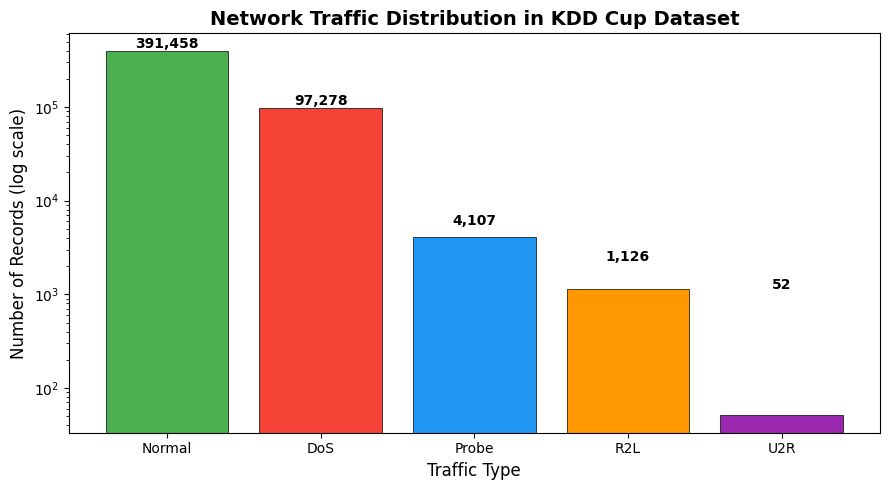

✅ Done — attack_distribution.png saved


In [ ]:
# Upload Yash's CSV first
from google.colab import files
uploaded = files.upload()  # Upload processed_df.csv here

df = pd.read_csv('processed_df.csv')

label_map = {0: 'Normal', 1: 'DoS', 2: 'Probe', 3: 'R2L', 4: 'U2R'}
df['label_name'] = df['label'].map(label_map)

label_counts = df['label_name'].value_counts()
colors = ['#4CAF50', '#F44336', '#2196F3', '#FF9800', '#9C27B0']

plt.figure(figsize=(9, 5))
bars = plt.bar(label_counts.index, label_counts.values, color=colors, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Network Traffic Distribution in KDD Cup Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Traffic Type', fontsize=12)
plt.ylabel('Number of Records (log scale)', fontsize=12)
plt.yscale('log')
plt.tight_layout()
plt.savefig('attack_distribution.png', dpi=150)
plt.show()
print("✅ Done — attack_distribution.png saved")

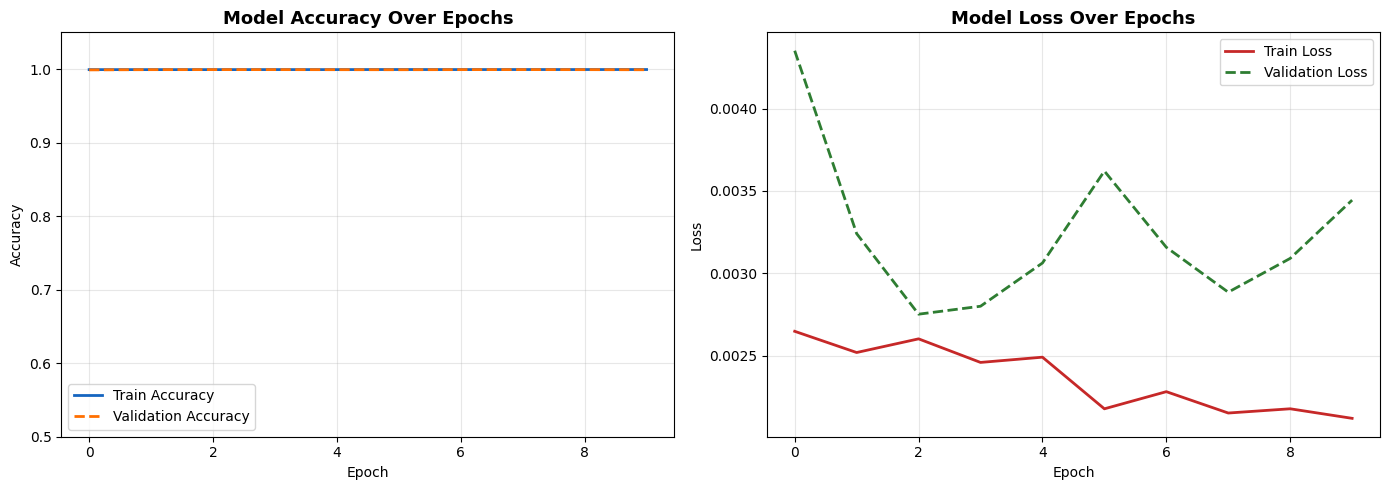

✅ Done — training_curves.png saved


In [ ]:
# 'history' is already in memory from Rushda's training cell — use it directly

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Train Accuracy', color='#1565C0', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#FF6F00', linewidth=2, linestyle='--')
ax1.set_title('Model Accuracy Over Epochs', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0.5, 1.05])

ax2.plot(history.history['loss'], label='Train Loss', color='#C62828', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', color='#2E7D32', linewidth=2, linestyle='--')
ax2.set_title('Model Loss Over Epochs', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print("✅ Done — training_curves.png saved")

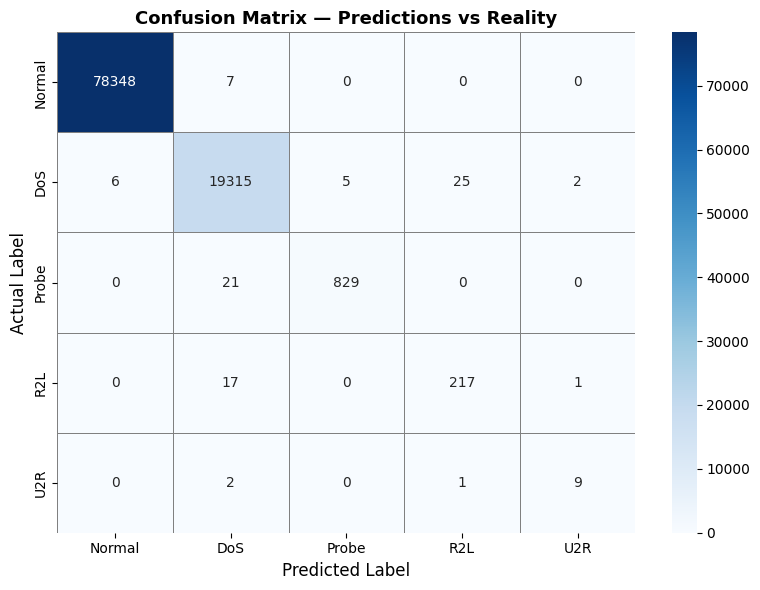

✅ Done — confusion_matrix.png saved


In [ ]:
# y_test and y_pred are already in memory from Rushda's cells

labels = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, linecolor='gray')

plt.title('Confusion Matrix — Predictions vs Reality', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("✅ Done — confusion_matrix.png saved")

In [ ]:
%whos

Variable                Type            Data/Info
-------------------------------------------------
Conv1D                  type            <class 'keras.src.layers.<...>olutional.conv1d.Conv1D'>
Dense                   type            <class 'keras.src.layers.core.dense.Dense'>
Dropout                 type            <class 'keras.src.layers.<...>ization.dropout.Dropout'>
Flatten                 type            <class 'keras.src.layers.<...>shaping.flatten.Flatten'>
LabelEncoder            type            <class 'sklearn.preproces<...>ing._label.LabelEncoder'>
MaxPooling1D            type            <class 'keras.src.layers.<...>_pooling1d.MaxPooling1D'>
MinMaxScaler            type            <class 'sklearn.preproces<...>sing._data.MinMaxScaler'>
Sequential              type            <class 'keras.src.models.sequential.Sequential'>
X                       DataFrame               duration  protoco<...>494021 rows x 41 columns]
X_scaled                ndarray         494021x41x1: 20

In [ ]:
import numpy as np
import time # Import time for sleep functionality

# model and X_test are already in memory from Rushda's cells

label_names = {
    0: ('✅  NORMAL       ', '🟢'),
    1: ('🚨 DoS ATTACK    ', '🔴'),
    2: ('🚨 PROBE ATTACK  ', '🔴'),
    3: ('🚨 R2L ATTACK    ', '🔴'),
    4: ('🚨 U2R ATTACK    ', '🔴'),
}

print("=" * 60)
print("     🛡️  NETWORK INTRUSION DETECTION SYSTEM")
print("         Real-Time Traffic Monitor — LIVE")
print("=" * 60)
print()

# Define the number of samples to pick for each class
num_samples_per_class = {
    0: 5,  # Normal
    1: 5,  # DoS
    2: 2,  # Probe
    3: 2,  # R2L
    4: 1   # U2R
}

selected_indices = []
# Iterate through each class to select a specific number of samples
for class_label, num_to_pick in num_samples_per_class.items():
    # Get indices of samples belonging to the current class in y_test
    class_indices = np.where(y_test == class_label)[0]
    # Randomly select 'num_to_pick' indices from this class
    # Ensure not to pick more than available samples for a class
    num_to_pick = min(num_to_pick, len(class_indices))
    selected_indices.extend(np.random.choice(class_indices, num_to_pick, replace=False))

# Shuffle the selected_indices to mix them up for a more diverse display
np.random.shuffle(selected_indices)

for i, idx in enumerate(selected_indices):
    sample = X_test[idx].reshape(1, X_test.shape[1], 1)
    probs = model.predict(sample, verbose=0)[0]
    pred = int(np.argmax(probs))
    confidence = probs[pred] * 100

    label_text, icon = label_names[pred]
    print(f"  Packet #{i+1:02d}  |  {label_text}  |  Confidence: {confidence:.1f}%")
    time.sleep(0.6)

print()
print("=" * 60)
print("  ✅ Scan complete. System standing by.")
print("=" * 60)

     🛡️  NETWORK INTRUSION DETECTION SYSTEM
         Real-Time Traffic Monitor — LIVE

  Packet #01  |  🚨 DoS ATTACK      |  Confidence: 100.0%
  Packet #02  |  🚨 PROBE ATTACK    |  Confidence: 100.0%
  Packet #03  |  ✅  NORMAL         |  Confidence: 100.0%
  Packet #04  |  ✅  NORMAL         |  Confidence: 100.0%
  Packet #05  |  🚨 R2L ATTACK      |  Confidence: 92.6%
  Packet #06  |  ✅  NORMAL         |  Confidence: 100.0%
  Packet #07  |  ✅  NORMAL         |  Confidence: 100.0%
  Packet #08  |  🚨 DoS ATTACK      |  Confidence: 100.0%
  Packet #09  |  ✅  NORMAL         |  Confidence: 100.0%
  Packet #10  |  🚨 U2R ATTACK      |  Confidence: 51.3%
  Packet #11  |  🚨 DoS ATTACK      |  Confidence: 100.0%
  Packet #12  |  🚨 R2L ATTACK      |  Confidence: 99.9%
  Packet #13  |  🚨 DoS ATTACK      |  Confidence: 100.0%
  Packet #14  |  🚨 DoS ATTACK      |  Confidence: 100.0%
  Packet #15  |  🚨 PROBE ATTACK    |  Confidence: 100.0%

  ✅ Scan complete. System standing by.
